# Building a Momentum Factor from Scratch and testing it against a Professional Benchmark
**Research question:** if I build a classic 12-month momentum long-short from
*free* Yahoo Finance data on today's S&P 500 members, how closely does it track
the professional CRSP-based benchmark from the [Open Source Asset Pricing](https://www.openassetpricing.com/)
(OSAP) project — and what does the gap between them reveal?

The notebook runs top to bottom:

1. **Download** monthly adjusted prices for the S&P 500 universe from `yfinance`.
2. **Filter** the universe to tickers with enough history to support the signal.
3. **Construct** the standard 12-month (skip-the-latest-month) momentum signal.
4. **Diagnose and fix a data glitch** — one bad price produces an impossible
   −115% portfolio month.By winsorizing extreme stock-month returns, the issue was fixed.
5. **Validate** the selfmade series against the OSAP/CRSP momentum benchmark.
6. **Decompose the return gap.** Mine earns only about a third of OSAP's *value-weight* benchmark. But comparing against OSAP's *equal-weight* benchmark, matched to my own weighting, closes roughly half the gap.

## Setup and imports

Install the two external-data packages (Open Source Asset Pricing and Yahoo
Finance) and import the scientific-Python stack used throughout.

In [23]:
# Install external data dependencies.
!pip install openassetpricing
!pip install yfinance

# Standard library
from io import StringIO

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import yfinance as yf
import openassetpricing

## 1. Building the investable universe

I start from the *current* list of S&P 500 members (scraped from Wikipedia) and
download monthly, split/dividend-adjusted closing prices back to 1990 from Yahoo
Finance. The single-ticker pull first confirms the feed works before scaling to
the full universe.

In [24]:
# Scrape the current S&P 500 constituent list from Wikipedia.
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0'}  # Wikipedia rejects the default urllib agent
html = requests.get(url, headers=headers).text

# The first HTML table on the page is the constituents table.
sp500 = pd.read_html(StringIO(html))[0]
tickers = sp500['Symbol'].tolist()

print('Number of tickers:', len(tickers))
print('First 10:', tickers[:10])

# Sanity-check the data feed on a single ticker before pulling the whole universe.
test = yf.download('AAPL', start='1990-01-01', interval='1mo', progress=False)
print('\nAAPL monthly rows:', len(test))
print('Columns:', list(test.columns))
test.tail(3)

Number of tickers: 503
First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

AAPL monthly rows: 439
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


/tmp/ipykernel_583/3879357047.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test = yf.download('AAPL', start='1990-01-01', interval='1mo', progress=False)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-05-01,312.059998,315.000000,274.859985,278.859985,981286400
2026-06-01,289.359985,317.399994,273.750000,309.630005,1401170100
2026-07-01,336.910004,339.570007,289.200012,293.440002,879201585


In [25]:
# Download monthly adjusted prices for the whole universe.
# auto_adjust=True (stated explicitly): 'Close' is split/dividend-adjusted.
raw = yf.download(tickers, start='1990-01-01', interval='1mo',
                  auto_adjust=True, progress=False)

# With many tickers, 'Close' is a DataFrame: rows = dates, cols = tickers.
prices = raw['Close'].copy()

print('Shape (months x tickers):', prices.shape)
print('Date range:', prices.index.min().date(), '->', prices.index.max().date())

# How complete is each ticker? Count non-missing months.
coverage = prices.notna().sum().sort_values()
print('\nTickers with FEWEST months of data:')
print(coverage.head(10))
print('\nTickers with zero data (failed downloads):', (coverage == 0).sum())

ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1mo 1990-01-01 -> 2026-07-28)')


Shape (months x tickers): (439, 503)
Date range: 1990-01-01 -> 2026-07-01

Tickers with FEWEST months of data:
Ticker
BRK.B     0
BF.B      0
HONA      2
FDXF      3
Q        10
SNDK     18
GEV      29
SOLV     29
VLTO     34
KVUE     39
dtype: int64

Tickers with zero data (failed downloads): 2


### Cleaning the universe

Two data-quality fixes. (1) Yahoo uses a dash rather than a dot for share-class
tickers, so `BRK.B` / `BF.B` come back empty and are re-pulled as `BRK-B` /
`BF-B`. (2) Tickers with fewer than 60 months of history are dropped, since the
12-month signal needs a few years of data to be meaningful.

In [26]:
# Fix 1: re-pull the two dot-tickers using yfinance's dash format.
fix_map = {'BRK.B': 'BRK-B', 'BF.B': 'BF-B'}
fixed = yf.download(list(fix_map.values()), start='1990-01-01', interval='1mo',
                    auto_adjust=True, progress=False)['Close']

# Rename the dash-tickers back to their original dot names so they match the universe.
fixed = fixed.rename(columns={v: k for k, v in fix_map.items()})

# Stitch the fixed columns back in.
prices[fixed.columns] = fixed

# Fix 2: drop tickers with too little history to support momentum.
MIN_MONTHS = 60  # need a few years; 60 = 5yr is a reasonable bar
coverage = prices.notna().sum()
keep = coverage[coverage >= MIN_MONTHS].index
prices = prices[keep]

print('Tickers kept (>=', MIN_MONTHS, 'months):', prices.shape[1])
print('Dropped for short history:', (coverage < MIN_MONTHS).sum())
print('Final panel shape:', prices.shape)

# Tickers dropped for short history (from coverage, which still has them all).
dropped_short = coverage[coverage < MIN_MONTHS].sort_values()
print('Dropped for short history:', len(dropped_short))
print(dropped_short)

Tickers kept (>= 60 months): 493
Dropped for short history: 10
Final panel shape: (439, 493)
Dropped for short history: 10
Ticker
HONA     2
FDXF     3
Q       10
SNDK    18
GEV     29
SOLV    29
VLTO    34
KVUE    39
GEHC    44
CEG     55
dtype: int64


## 2. Constructing the momentum signal

The classic momentum signal is the trailing 12-month return **skipping the most
recent month** (to sidestep short-term reversal). It is computed purely from
prices at *t*−1 and *t*−12, so the signal never peeks at the future.

In [27]:
# Build the momentum signal: past-12m return, skipping the most recent month.

# Monthly simple returns for every stock.
rets = prices.pct_change(fill_method= None)

# 12-month momentum skipping the most recent month:
# cumulative return from t-12 to t-1 (shift the 12m window back by 1 month).
mom = (prices.shift(1) / prices.shift(12)) - 1  # uses t-1 and t-12 only -> no look-ahead

print('Momentum signal shape:', mom.shape)
print('Example (first few tickers, one recent month):')
print(mom.iloc[-1].dropna().head())

Momentum signal shape: (439, 493)
Example (first few tickers, one recent month):
Ticker
A       0.166239
AAPL    0.399566
ABBV    0.362887
ABNB    0.080734
ABT    -0.269515
Name: 2026-07-01 00:00:00, dtype: float64


## 3. Forming the long-short portfolio

Each month I rank stocks by the signal, go long the top decile (>90th percentile)
and short the bottom decile (≤10th percentile), equal-weighted. I build the
long-short from **raw, uncleaned** returns first — not because it is correct,
but because it exposes a data glitch that the cleaning step then fixes.

In [28]:
# Rank cross-sectionally each month, then form the decile long-short.
ranks = mom.rank(axis=1, pct=True)
long_mask = ranks > 0.9    # top decile
short_mask = ranks <= 0.1  # bottom decile

# RAW version (uncleaned rets) -- kept ONLY to expose the data glitch.
fwd_raw = rets.shift(-1)
my_mom_raw = (fwd_raw[long_mask].mean(axis=1)
              - fwd_raw[short_mask].mean(axis=1)).dropna()

print('Raw   min monthly LS:', round(my_mom_raw.min(), 4))  # the -1.15 glitch

Raw   min monthly LS: -1.1508


## 4. Diagnosing a data glitch

Building from free (yfinance) data surfaces price errors that professional
databases pre-clean. One stock's erroneous return produces an impossible
−115% portfolio month, which breaks the compounded growth curve below. The
next cells rule out an index problem and pinpoint the offending month before
deciding how to handle it.

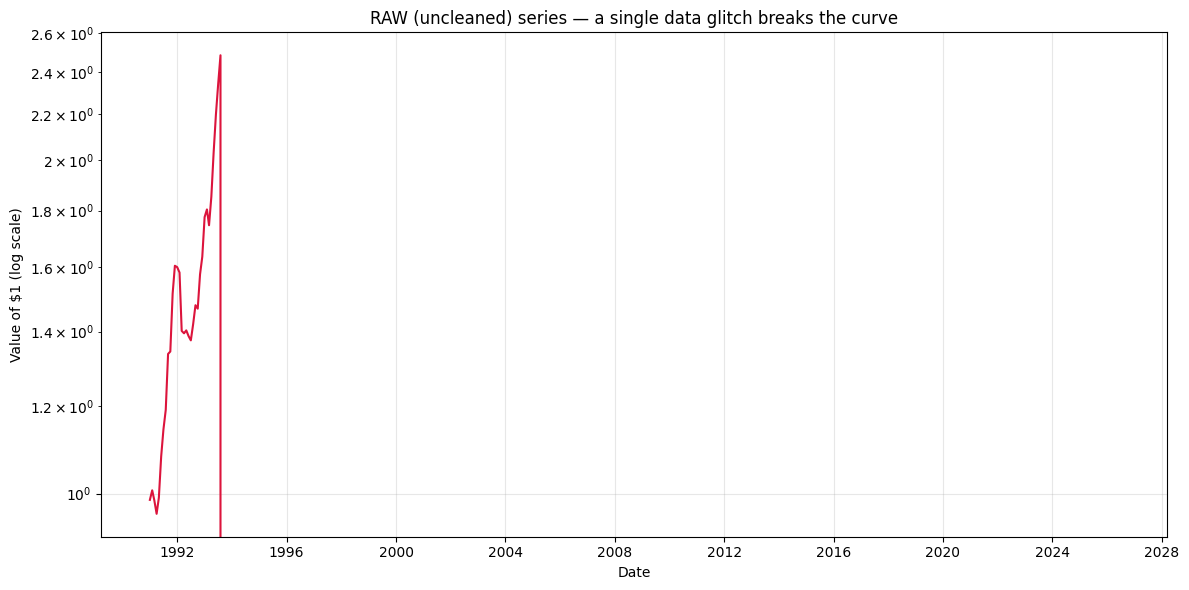

In [29]:
# Compounded growth of $1 on the RAW series (log scale to see the whole range).
growth_raw = (1 + my_mom_raw).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(growth_raw.index, growth_raw.values, color='crimson')
ax.set_yscale('log')
ax.set_title('RAW (uncleaned) series — a single data glitch breaks the curve')
ax.set_xlabel('Date')
ax.set_ylabel('Value of $1 (log scale)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mom_growth_raw.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Locate the extreme months driving the broken curve.
print('Max monthly return:', my_mom_raw.max(), 'on', my_mom_raw.idxmax())
print('Min monthly return:', my_mom_raw.min(), 'on', my_mom_raw.idxmin())
print('\nThe 5 most extreme months:')
print(my_mom_raw.abs().sort_values(ascending=False).head())

Max monthly return: 0.42633951260529973 on 2000-01-01 00:00:00
Min monthly return: -1.1507981905717335 on 1993-09-01 00:00:00

The 5 most extreme months:
Date
1993-09-01    1.150798
2009-03-01    0.558144
2000-01-01    0.426340
2000-12-01    0.377431
2002-10-01    0.337518
dtype: float64


### The fix: winsorize extreme stock-month returns

A single stock realistically won't move more than about ±100% in a month, so I
cap monthly stock returns to [−90%, +100%] before forming portfolios and rebuild
the long-short; only a tiny fraction of observations are affected. I also shift
the return index forward one month so each portfolio return is dated by the month
it was *earned*, which lines up with the OSAP benchmark later.

In [31]:
# Clean underlying stock returns before forming portfolios.
# A single stock realistically won't move more than ~100% in a month; beyond
# that is a data glitch. Cap monthly stock returns to [-90%, +100%].
rets_clean = rets.clip(lower=-0.9, upper=1.0)

# How many values did we actually cap? (should be a tiny handful)
n_capped = ((rets < -0.9) | (rets > 1.0)).sum().sum()
print('Stock-month returns capped:', n_capped, 'out of', rets.notna().sum().sum())

# Rebuild the long-short using the CLEANED returns.
fwd_ret = rets_clean.shift(-1)
long_ret = fwd_ret[long_mask].mean(axis=1)
short_ret = fwd_ret[short_mask].mean(axis=1)
my_mom = (long_ret - short_ret).dropna()

# Date each return by the month it was EARNED (t+1), aligning with OSAP later.
my_mom.index = my_mom.index + pd.DateOffset(months=1)

print('New max monthly LS return:', round(my_mom.max(), 4))
print('New min monthly LS return:', round(my_mom.min(), 4))

Stock-month returns capped: 46 out of 174086
New max monthly LS return: 0.3985
New min monthly LS return: -0.5046


## 5. The corrected growth curve

After winsorizing 46 of 174,086 stock-month returns to [−90%, +100%]
(0.03% of observations), the growth curve renders correctly and shows the
2008–09 momentum crash and the subsequent decade of flat performance.

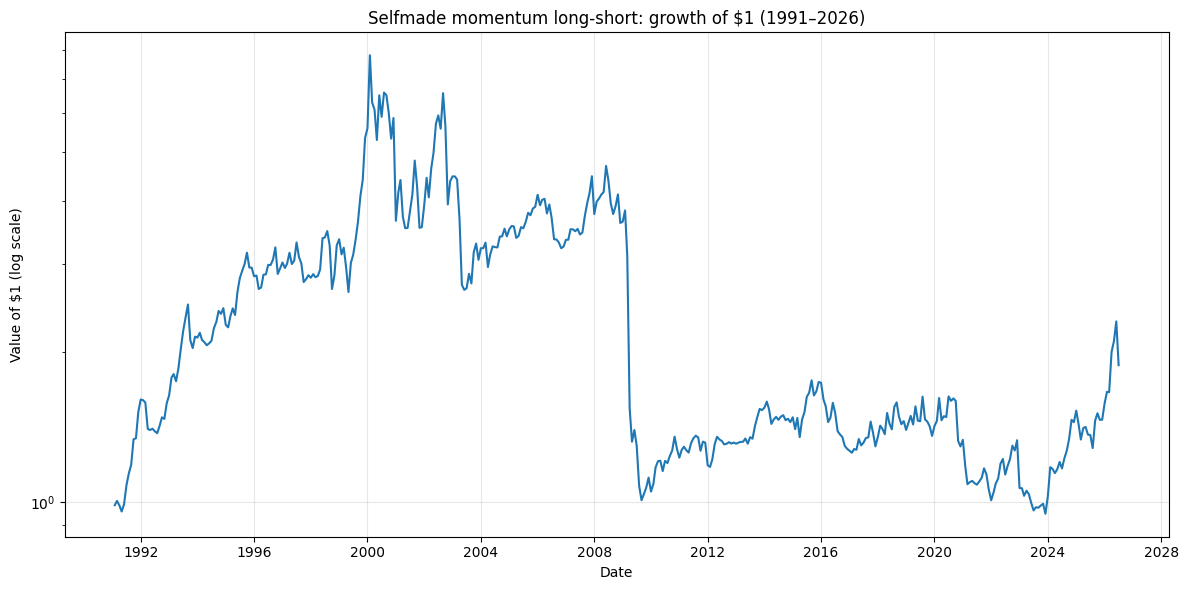

In [32]:
# Compounded growth of $1 on the CORRECTED series.
growth_1 = (1 + my_mom).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(growth_1.index, growth_1.values)
ax.set_yscale('log')  # log scale -- same reasoning as before
ax.set_title('Selfmade momentum long-short: growth of $1 (1991–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Value of $1 (log scale)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('my_mom_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Validating against the OSAP / CRSP benchmark

Is my homemade factor really *momentum*? I compare it against the professional
`Mom12m` value-weighted and equal- weighted deciles long-short from the Open Source Asset Pricing
project, built on survivorship-bias-free CRSP data. First I instantiate the OSAP
client and inspect the methods it exposes.

In [33]:
# Explore the package, then instantiate the OSAP client.
dir(openassetpricing)
op = openassetpricing.OpenAP()

# Inspect the client's methods (dl_port is the one used below).
dir(op)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_convert_to_backend',
 '_dl_individual_signal',
 '_dl_port_alt',
 '_dl_port_op',
 '_dl_signal',
 '_dl_signal_crsp3',
 '_get_individual_signal_url',
 '_get_url',
 '_port_indiv',
 '_print_time',
 '_zip_source',
 'dl_all_signals',
 'dl_port',
 'dl_signal',
 'dl_signal_doc',
 'individual_signal_id_map',
 'list_port',
 'name_id_map',
 'signal_sign',
 'url']

In [34]:
op.list_port()

┌─────────────────────────────────────────────────┬─────────────────────┐
│ CZ portfolio file                               │ Name for download   │
├─────────────────────────────────────────────────┼─────────────────────┤
│ PredictorAltPorts_Deciles.zip                   │ deciles_ew          │
│ PredictorAltPorts_DecilesVW.zip                 │ deciles_vw          │
│ PredictorAltPorts_LiqScreen_ME_gt_NYSE20pct.zip │ ex_nyse_p20_me      │
│ PredictorAltPorts_LiqScreen_NYSEonly.zip        │ nyse                │
│ PredictorAltPorts_LiqScreen_Price_gt_5.zip      │ ex_price5           │
│ PredictorAltPorts_Quintiles.zip                 │ quintiles_ew        │
│ PredictorAltPorts_QuintilesVW.zip               │ quintiles_vw        │
│ PredictorPortsFull.csv                          │ op                  │
└─────────────────────────────────────────────────┴─────────────────────┘


In [35]:
# Pull the OSAP momentum benchmark and align it with the selfmade series.
osap = op.dl_port('deciles_vw', 'pandas', ['Mom12m'])
osap_ls = osap[osap['port'] == 'LS'].copy()
osap_ls['date'] = pd.to_datetime(osap_ls['date'])
osap_ls = osap_ls.sort_values('date')
osap_series = osap_ls.set_index('date')['ret'] / 100  # percent -> decimal

# Align on a common monthly key. my_mom was already shifted forward one month
# above, so it is labeled by the month the return was EARNED (matching OSAP);
# here we just collapse both series to a year-month period key.
mine = my_mom.copy()
mine.index = mine.index.to_period('M')
osap_m = osap_series.copy()
osap_m.index = osap_m.index.to_period('M')

# Join on the shared months only.
comp = pd.DataFrame({'mine': mine, 'osap': osap_m}).dropna()
print('Overlapping months:', len(comp))
print('Date range:', comp.index.min(), '->', comp.index.max())

# (1) Did I capture the same PATTERN?
correlation = comp['mine'].corr(comp['osap'])
print('\nCorrelation (mine vs OSAP):', round(correlation, 3))


# (2) The MAGNITUDE gap (annualized, on the overlapping window).
def quick_stats(r):
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    return ann_ret, ann_ret / ann_vol


mine_ret, mine_sharpe = quick_stats(comp['mine'])
osap_ret, osap_sharpe = quick_stats(comp['osap'])
print(f"\nMine  : ann return {mine_ret:.2%}, Sharpe {mine_sharpe:.2f}")
print(f"OSAP  : ann return {osap_ret:.2%}, Sharpe {osap_sharpe:.2f}")

# --- (3) Second benchmark: OSAP EQUAL-WEIGHT, matched to my own equal-weighting ---
# Comparing EW-to-EW removes the weighting confound, isolating the effect of
# universe/survivorship from the effect of equal- vs value-weighting.
osap_ew = op.dl_port('deciles_ew', 'pandas', ['Mom12m'])
osap_ew_ls = osap_ew[osap_ew['port'] == 'LS'].copy()
osap_ew_ls['date'] = pd.to_datetime(osap_ew_ls['date'])
osap_ew_series = (osap_ew_ls.sort_values('date').set_index('date')['ret'] / 100)
osap_ew_m = osap_ew_series.copy()
osap_ew_m.index = osap_ew_m.index.to_period('M')

comp_ew = pd.DataFrame({'mine': mine, 'osap_ew': osap_ew_m}).dropna()
corr_ew = comp_ew['mine'].corr(comp_ew['osap_ew'])
ew_ret, ew_sharpe = quick_stats(comp_ew['osap_ew'])

print(f"\nOSAP (equal-weight): ann return {ew_ret:.2%}, Sharpe {ew_sharpe:.2f}")
print(f"Correlation (mine vs OSAP-EW): {round(corr_ew, 3)}")
print(f"\nGap vs value-weight benchmark: {osap_ret - mine_ret:.2%}")
print(f"Gap vs equal-weight benchmark: {ew_ret - mine_ret:.2%}")


Data is downloaded: 2s
Overlapping months: 407
Date range: 1991-02 -> 2024-12

Correlation (mine vs OSAP): 0.795

Mine  : ann return 4.92%, Sharpe 0.19
OSAP  : ann return 15.18%, Sharpe 0.45

Data is downloaded: 3s

OSAP (equal-weight): ann return 9.20%, Sharpe 0.30
Correlation (mine vs OSAP-EW): 0.684

Gap vs value-weight benchmark: 10.25%
Gap vs equal-weight benchmark: 4.28%


## Same pattern, different magnitude

The two series are strongly correlated (≈ 0.79) — mine captures the same monthly pattern as the benchmark — but the annualized return is far lower (≈ 5% vs the value-weight benchmark's ≈ 15%). The scatter below plots my monthly returns against OSAP's: the points cluster around an upward-sloping best-fit line whose slope sits well below the y = x line, visualizing the magnitude gap.

That raw gap, however, is not all survivorship. Compared against OSAP's *value-weight* benchmark the shortfall is ≈ 10.3pp; compared against its *equal-weight* benchmark — matched to my own equal-weighting — it shrinks to ≈ 4.3pp. So **weighting alone accounts for more than half the apparent gap.** The residual ≈ 4.3pp reflects my large-cap-only universe (momentum is strongest in the smaller stocks OSAP reaches) and survivorship (I omit the delisted losers a short-momentum leg profits from).

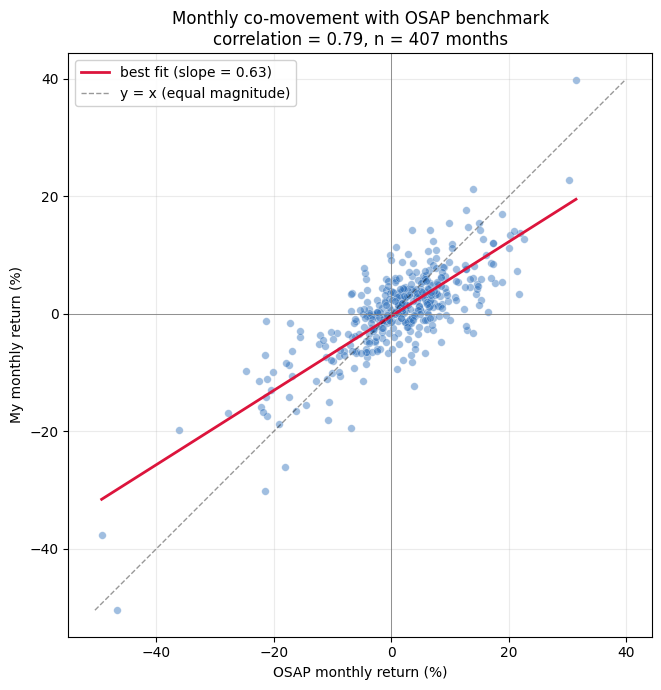

In [36]:
fig, ax = plt.subplots(figsize=(7, 7))

# Scatter: each point is one overlapping month (returns shown in percent).
ax.scatter(comp['osap'] * 100, comp['mine'] * 100,
           alpha=0.45, s=30, color='#2c6fbb', edgecolor='white', linewidth=0.4)

# Actual best-fit line (shows the real relationship / slope).
slope, intercept = np.polyfit(comp['osap'], comp['mine'], 1)
xline = np.array([comp['osap'].min(), comp['osap'].max()])
ax.plot(xline * 100, (slope * xline + intercept) * 100,
        color='crimson', lw=2, label=f'best fit (slope = {slope:.2f})')

# y = x reference (perfect one-to-one) for contrast.
lim = [comp[['osap', 'mine']].min().min() * 100,
       comp[['osap', 'mine']].max().max() * 100]
ax.plot(lim, lim, 'k--', alpha=0.4, lw=1, label='y = x (equal magnitude)')

ax.axhline(0, color='gray', lw=0.6)
ax.axvline(0, color='gray', lw=0.6)
ax.set_xlabel('OSAP monthly return (%)')
ax.set_ylabel('My monthly return (%)')
ax.set_title(f'Monthly co-movement with OSAP benchmark\n'
             f'correlation = {correlation:.2f}, n = {len(comp)} months',
             fontsize=12)
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig('mom_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

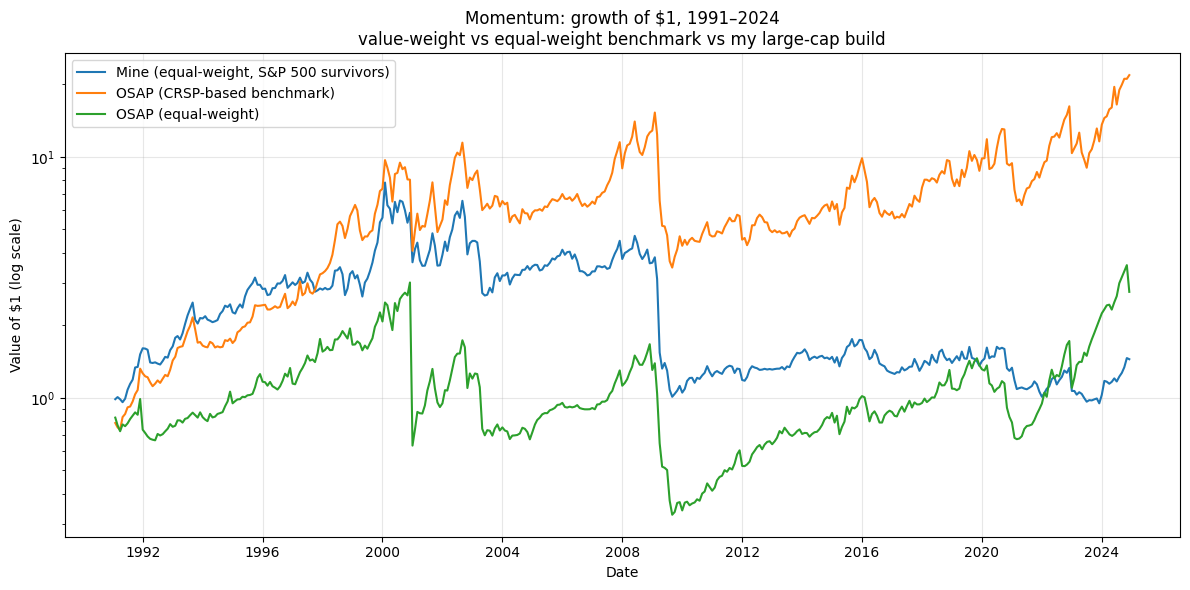

In [37]:
# Closing chart: growth of $1 for my series vs BOTH OSAP benchmarks (VW and EW)
mine_dec = comp['mine']
osap_dec = comp['osap']
osap_dec_ew = comp_ew['osap_ew']

# Compound each monthly return series into a growth-of-$1 curve.
g_mine = (1 + mine_dec).cumprod()
g_osap = (1 + osap_dec).cumprod()
g_osap_ew = (1 + osap_dec_ew).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(g_mine.index.to_timestamp(), g_mine.values,
        label='Mine (equal-weight, S&P 500 survivors)')
ax.plot(g_osap.index.to_timestamp(), g_osap.values,
        label='OSAP (CRSP-based benchmark)')
ax.plot(g_osap_ew.index.to_timestamp(), g_osap_ew.values,
        label='OSAP (equal-weight)')
ax.set_yscale('log')
ax.set_title('Momentum: growth of $1, 1991–2024\nvalue-weight vs equal-weight benchmark vs my large-cap build')
ax.set_xlabel('Date')
ax.set_ylabel('Value of $1 (log scale)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mom_vs_osap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusion: Decomposing the gap between free and professional data

Built from nothing but free Yahoo Finance prices, the from-scratch momentum
long-short reproduces the *shape* of the professional CRSP benchmark remarkably
well, correlation ≈ 0.79 against OSAP's value-weight series across 407 months
(1991–2024), while capturing only a fraction of its *size*: ≈ 5%

1.   List item
2.   List item

annualized
(Sharpe 0.19) versus ≈ 15% (Sharpe 0.45). Pulling **both** OSAP benchmarks lets
me decompose that ≈ 10.3pp shortfall instead of attributing all of it to
survivorship.

**Weighting is the single largest driver.** OSAP's *value-weight* benchmark
returns ≈ 15%, but its *equal-weight* benchmark — matched to my own
equal-weighting — returns only ≈ 9%. Putting the comparison on equal footing
closes ≈ 6pp, or **more than half (≈ 58%) of the raw gap.** Measured against the
correctly matched equal-weight benchmark, my shortfall is ≈ 4.3pp, not ≈ 10.3pp.

**The residual ≈ 4.3pp is universe + survivorship — and free data can't cleanly
separate the two.** Both push the same way: (i) I trade only large caps, and
momentum is historically strongest among the smaller stocks that OSAP's full-CRSP
universe reaches; and (ii) I hold only today's S&P 500 survivors, so the delisted
losers that a short-momentum leg profits from never enter my sample. The
correlation also loosens from 0.79 (value-weight) to 0.68 (equal-weight) — a
reminder that even the "matched" benchmark is not a perfect twin of my large-cap, survivor-only universe.

**Takeaway.** The honest headline is *not* "survivorship bias costs two-thirds of
the momentum premium." It is that a naive free-data backtest understates the
professional result for several compounding reasons, and once you control for the
biggest and most mundane one — portfolio weighting — the gap that remains for
universe and survivorship is real but modest (≈ 4pp). The broader lesson for
factor prototyping: a near-perfect correlation with the right answer can still sit
on top of a badly mis-scaled return, and separating "my data is biased" from
"my construction differs" requires matching the benchmark choice by choice —
exactly what the value-weight vs equal-weight comparison does here.




